# Ders 2 — Gradyan İnişi ve İlk Modelimiz

**Program:** Python ile Derin Öğrenme Tabanlı Görüntü ve Doğal Dil İşleme
**Modül 1 · Oturum 2** · Önerilen süre: 4 saat

## Bu oturumun hedefleri
1. **Maliyet fonksiyonu** kavramını tanımlamak: modelin yanlışlığının tek bir sayıya indirgenmesi
2. Gradyan inişini **numpy ile elle** kodlayarak güncelleme kuralını içselleştirmek
3. Aynı hesabın `torch.autograd` ile otomatik yapıldığını **gradyan eşitliğiyle** doğrulamak *(Derinleşme bölümünde: autograd Oturum 03'ün konusudur; ana akışta elle türevle çalışırız)*
4. **Batch, epoch, öğrenme hızı (lr)** terimlerini eğitim döngüsüyle eşleştirmek
5. `nn.Linear` + `SGD` ile ilk PyTorch modelini eğitmek; aktivasyon fonksiyonlarını grafikle tanımak
6. **Bölüm sonu uygulaması:** tek nöronla 8×8 rakamların 0/1 ayrımını eğitmek ve modelin 64 ağırlığını
   8×8 ısı haritası olarak okumak — "model nereye bakıyor?"

> **Nasıl çalışılır:** Hücreleri yukarıdan aşağıya `Shift+Enter` ile çalıştır.
> Sarı kutular animasyonlu anlatım videolarıdır (HyperFrames ile üretildi).

## Sezgi Girişi: Günlük Yaşamdan Üç Benzetme

Formülden önce gündelik hayattan tanıyalım; bu oturumda öğreneceğimiz her düşünce bu üç sahnede bir karşılık bulur.

**Taksi ücreti — model ve parametre benzetmesi.** Taksinin tarifesi iki ayarlıdır: kapı açılış ücreti ve kilometre başına ödenen kısa ücret. Nereden biliyorsun 12 kilometrelik bir yolculuğun tutarını? Şoför iki ayarı kullanarak bir hesap yapar. Yapay öğrenmenin ilk sorusu tam budur: elinde (mesafe, tutar) çiftleri varken "iki ayardan hangi değerler doğru tarifeyi üretir?" — biz de bu ayarları veriye bakarak bulmayı öğreniriz. Ayarların o kadar değerleri modelin **parametreleri**dir.

**Dart tahtası — kayıp benzetmesi.** Atıcı merkeze vurmayı ister; ancak "iyi atış mı, kötü atış mı" sorusuna cevap vermek için tek bir sayı gerekir: her okun merkezden uzaklığının toplamı. Modelin tahminleri oktur, gerçekte gerçekleşen değer merkezdir; tüm tahminlerin toplam yanlışlığı tek sayıya indirgenir — adına **kayıp** diyeceğiz. Bu sayı ne kadar düşükse model o kadar iyi çalışıyor demektir.

**Dağda vadiye inmek — gradyan inişi benzetmesi.** Sisli bir dağın tepesindesin ve derin vadiye inmen gerekiyor, ama dibi gözünle görmüyorsun (tüm olası parametre değerlerini tek tek deneyemezsin). Ne yapıyorsun? Her adımda ayakta hissettiğin **eğimi** incelersin: aşağıya doğru eğimli yön hangi taraf ise oraya küçük bir adım atarsın, sonra yeniden eğim bakarsın. Model öğrenirken tam bunu yapar: her adımda kaybın **arttığı** yönün tersine, küçük bir adım atar.

In [22]:
# sklearn bulunamazsa devreye girecek sentetik örüntü üreteci: "0" = parlak halka/çerçeve, "1" = dikey çubuk
import numpy as np

def sentetik_rakamlar(n=60):
    g = np.random.default_rng(0)                    # sabit tohum: herkes aynı veriyi görür
    goruntuler = np.zeros((n, 8, 8))                # n adet 8x8 siyah zemin tablosu
    hedefler = np.concatenate([np.zeros(n // 2), np.ones(n - n // 2)]).astype(int)
    yy, xx = np.mgrid[0:8, 0:8]                     # piksel koordinatları (satır, sütun)
    for i in range(n):
        if hedefler[i] == 0:                        # 0 rakamı: kenarlar parlak, merkez karanlık
            maske = (xx == 0) | (xx == 7) | (yy == 0) | (yy == 7)
        else:                                       # 1 rakamı: ortadaki dikey çubuk
            maske = (xx == 4)
        goruntuler[i][maske] = 16.0                 # parlak pikseller 0-16 ölçeğinin tepesine
        goruntuler[i] += g.normal(0, 1.5, size=(8, 8))  # hafif gürültü: ezberlemeyi engeller
    return np.clip(goruntuler, 0, 16), hedefler     # değerler 0-16 aralığında kalsın

## Ana Veri: 8×8 Piksellik Rakamlar

Bu oturumun çalışacağı veri, bir görüntü veri kümesinin minicik hâli: elle yazılmış rakamlar **8×8 piksel**'e küçültülüp bir sayı tablosuna dönüşmüş — her rakam artık 64 sayıdan oluşan bir piksel parlaklık tablosudur (0-16 arası, 0 = tamamen karanlık). Bugün yalnızca iki rakamı ayıracağız: **0** ve **1**; oturum sonundaki uygulama, bu 64 sayının her birine bir ağırlık veren tek bir nöronu eğitecek.

> **İnternet/kütüphane yoksa ne olur?** Alttaki hücre `sklearn` bulunamazsa aynı boyutta (8×8) iki sentetik örüntü (halka ve çubuk) üretir; dersin akışı değişmez.

In [23]:
# Ana veriyi yükle: sklearn varsa gerçek el yazısı rakamlar, yoksa sentetik örüntüler
try:
    from sklearn.datasets import load_digits
    d, t = load_digits(return_X_y=True)
    veriler, hedefler = d.reshape(-1, 8, 8), t      # 64 sayıyı 8x8 tabloya geri aç
    kaynak = "sklearn digits (8x8 el yazısı rakamlar)"
except Exception as hata:
    print(f"sklearn yok ({hata.__class__.__name__}) -> sentetik örüntülerle devam ediyoruz")
    veriler, hedefler = sentetik_rakamlar(60)       # bir önceki hücrede tanımlandı
    kaynak = "sentetik örüntüler (halka = 0, çubuk = 1)"

print(f"veri hazır: {len(veriler)} örnek | her biri 8x8 piksel | kaynak: {kaynak}")


veri hazır: 1797 örnek | her biri 8x8 piksel | kaynak: sklearn digits (8x8 el yazısı rakamlar)


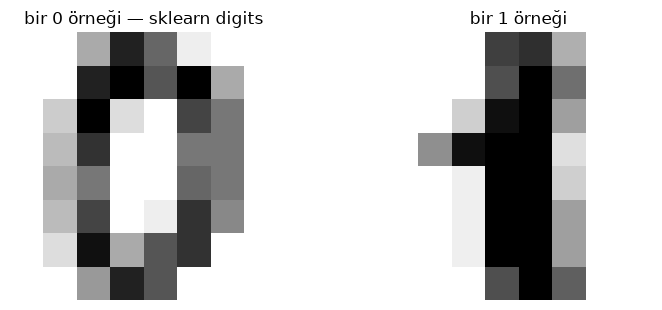

bir rakam 64 sayıdır: 8 satır x 8 sütun piksel parlaklığı.


In [24]:
# Veriye göz atalım: bir adet 0 ve bir adet 1, yan yana gri tonlu tablo olarak
import numpy as np
import matplotlib.pyplot as plt

ilk0, ilk1 = veriler[hedefler == 0][0], veriler[hedefler == 1][0]   # her sınıftan bir örnek
fig, eksenler = plt.subplots(1, 2, figsize=(8, 3.2))
for eksen, gorsel, ad in [(eksenler[0], ilk0, f"bir 0 örneği — {kaynak.split(' (')[0]}"),
                          (eksenler[1], ilk1, "bir 1 örneği")]:
    eksen.imshow(gorsel, cmap="gray_r")             # piksel parlaklıkları gri tonlarda
    eksen.set_title(ad)
    eksen.axis("off")                               # piksel eksenlerini gizleyelim
plt.tight_layout(); plt.show()
print(f"bir rakam {ilk0.size} sayıdır: 8 satır x 8 sütun piksel parlaklığı.")


## 1 · Maliyet Fonksiyonu: Model Ne Kadar Yanılıyor?

Bir doğrusal model $\hat{y} = w \cdot x + b$ düşünelim. $w$ (ağırlık) ve $b$ (sapma) modelin **parametreleridir**; öğrenmek, bu sayıları doğru seçmek demektir. Peki "doğru"yu nasıl ölçeriz?

**Maliyet (kayıp) fonksiyonu**, tahminlerle gerçekler arasındaki farkı **tek bir sayıya** indirger. Regresyonda en yaygını **Ortalama Kare Hata (MSE)**:

$$C(w, b) = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{y}_i - y_i\right)^2$$

Kare aldığımız için büyük hatalar daha çok cezalandırılır ve işaret kaybolur.

Doğrusal modellerde $C(w)$, $w$'ye göre **U şeklinde** (konveks) bir eğridir: en dipteki nokta = en iyi parametre. Öğrenme, bu vadinin dibini aramaktır:

| | Anlamı |
|---|---|
| Vadideki **yükseklik** | maliyet $C$ — modelin toplam yanlışlığı |
| Eğrinin **eğimi** | gradyan $\frac{\partial C}{\partial w}$ — "hangi yönde daha kötüyüm" |
| **Vadinin dibi** | gradyan sıfır — ideal parametre

### Arka plandaki matematik

Gradyan inişinin arkasındaki tek fikir: hatayı tek bir sayı olan maliyet $C$'ye indirgemek, sonra bu sayıyı azaltacak yönde adım atmak. Doğrusal model $\hat{y} = wx + b$ ve ortalama kare hata için:

$$C(w,b) = \frac{1}{N}\sum_{i=1}^{N}\left(wx_i + b - y_i\right)^2$$

**Sayısal örnek (elle):** tek örnek $x=1$, gerçek $y=3$; parametreler $w=0.5,\ b=0$:
- Tahmin: $\hat{y} = 0.5\times 1 + 0 = 0.5$; hata: $0.5 - 3 = -2.5$
- Kayıp: $C = (-2.5)^2 = 6.25$; eğim: $\dfrac{\partial C}{\partial w} = 2(-2.5)(1) = -5$
- Güncelleme ($\text{lr}=0.1$): $w \leftarrow 0.5 - 0.1\times(-5) = 1.0$, $b \leftarrow 0 - 0.1\times(-5) = 0.5$. Yeni tahmin $1.2$, yeni kayıp $(-1.8)^2 = 3.24 < 6.25$ — iniş işe yaradı.

> Bu blok, alttaki animasyonun anlattığı gradyan inişi için gerekli: formülü görmeden "en dik iniş" deyimi havada kalır; bu mini hesap, adımın nereye ve neden gittiğini sayılarla gösterir.

#### Satır satır
- `from IPython.display import Video` → `Video` sınıfını getirir: video dosyasını notebook hücresinin içine gömmeye yarar. Neden: eğitimi animasyonla görmek, kuru formülden daha akılda kalıcı. Yarar: her klip tek satırla kurulur.
- `# 1.1 — U-şekli maliyet eğrisi ...` → yorum satırı: klipin konusunu özetler, çalışmayı etkilemez.
- `Video("assets/01-gradyan-inisi.mp4", width=1000, embed=True)` → videoyu hücre çıktısına gömer. `embed=True` video verisini notebook dosyasının içine işler (dosyanın yeri değişse bile oynar); `width=1000` görüntü genişliğini piksel cinsinden belirler. Neden: her klip kendi başına çalışabilir olmalı. Yarar: `Shift+Enter` ile klip anında oynar.

In [25]:
from IPython.display import Video

# 1.1 — U-şekli maliyet eğrisi üzerinde gradyan inişi (3 farklı lr denemesi)
Video("assets/01-gradyan-inisi.mp4", width=1000, embed=True)

### Gradyan inişi: en dik iniş yönünde küçük adımlar

Gradyan, maliyetin **en hızlı arttığı** yönü gösterir. Azaltmak için tersi yönde ilerleriz:

$$w \leftarrow w - \eta \cdot \frac{\partial C}{\partial w}$$

Buradaki $\eta$ (eta) **öğrenme hızı (learning rate, lr)**: her adımın boyu. Animasyondaki üç denemenin özeti:

| lr | Davranış | Sonuç |
|---|---|---|
| $0.001$ | Minicik adımlar | Güvenli ama **çok yavaş** |
| $0.1$ | Dengeli adımlar | Hızla vadiye ulaşır |
| $1.0$ | Dev adımlar | Minimumun **üzerinden atlar**, salınır

### Arka plandaki matematik

Batch/epoch matematiği basitçe bölme ve sayma işidir: $N$ örnek, batch boyutu $B$ ise bir epoch'taki güncelleme (iterasyon) sayısı $\lceil N/B \rceil$'dir.

**Sayısal örnek (elle):** $N=500$, $B=100$:
- Her epoch: $500/100 = 5$ güncelleme adımı (5 iterasyon)
- 10 epoch: $5 \times 10 = 50$ güncelleme
- Her adımda gradyan yalnız o adımın 100 örneğinden hesaplanır: $\dfrac{\partial C_{\text{batch}}}{\partial w} = \dfrac{2}{100}\sum_{i \in \text{batch}}(\hat{y}_i - y_i)\,x_i$ — 500 örneğin tam toplamının ucuz kestirimi; gürültülü ama çok daha hızlı.

> Bu blok, alttaki klipin anlattığı batch/epoch/lr ritmi için gerekli: adım sayısını elle saymak, sonraki demo (c)'teki iç içe döngülerin neden var olduğunu açıklar.

#### Satır satır
- `# 1.2 — Eğitimin ritmi ...` → yorum: klipin konusu.
- `Video("assets/02-batch-epoch-lr.mp4", width=1000, embed=True)` → batch/epoch/öğrenme hızı kavramlarını anlatan klipin notebook'a gömer. (`from IPython.display import Video` ilk klip hücresinde yapıldığı için tekrar gerekmez.) Neden: her klip ayrı hücrede, kendi başına çalışabilir olmalı. Yarar: kavramları önce görerek, sonra sayılarla öğreneceğiz.

In [26]:
# 1.2 — Eğitimin ritmi: veri yığını → mini-batch'ler → epoch sayacı
Video("assets/02-batch-epoch-lr.mp4", width=1000, embed=True)

## Matematik Kutusu: Türevin Sezgisi — "Ağırlığı Azıcık Kaydırınca Ne Olur?"

**Sembolsüz dil önce.** Türev şu sorunun tek sayılık cevabıdır: *ağırlığı çok küçük bir miktar artırırsam kayıp hangi yöne ve ne hızla değişir?* Cevap negatifse kayıp **azalıyordur** — "ağırlığı artır, iş yarar"; pozitifse kayıp artıyordur — "geri çekil". Sayı büyüdükçe kayıp o kadar hızlı değişir; adım genişliği de bu yüzden ölçeklenir.

**Tek formül.** Doğrusal model $\hat{y} = wx$ (sapmayı şimdilik ihmal ediyoruz) ve MSE kaybı için:

$$\frac{\partial C}{\partial w} = \frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)\,x_i$$

> Okunuşu: "her örneğin hatasını al, girdisiyle çarp ve ortalama" — hata negatifse (az tahmin ettik) türevi de negatif çıkar ve kural bize ağırlığı **artırmayı** söyler; tam da ihtiyacımız olan yönde.

**Elle sayısal örnek (3 adım, kalemle):** tek örnek $x=1$, gerçek $y=3$; başlangıç $w=0.5$, lr $=0.1$:

| Adım | $\hat{y} = w$ | hata $\hat{y}-y$ | kayıp $(\hat{y}-y)^2$ | eğim $2(\hat{y}-y)x$ | güncelleme $w \leftarrow w - \text{lr}\cdot$eğim |
|---|---|---|---|---|---|
| 1 | $0.50$ | $-2.5$ | $6.25$ | $-5$ | $0.5 - 0.1(-5) = \mathbf{1.00}$ |
| 2 | $1.00$ | $-2.0$ | $4.00$ | $-4$ | $1.0 - 0.1(-4) = \mathbf{1.40}$ |
| 3 | $1.40$ | $-1.6$ | $2.56$ | $-3.2$ | $1.4 - 0.1(-3.2) = \mathbf{1.72}$ |

Her adımda kayıp **düştü** ($6.25 \to 4.00 \to 2.56$): eğimler negatif çıktığı için ağırlık hep arttı — vadiye doğru. Alttaki hücre tam bu üç adımı numpy ile hesaplayıp ekrana yazdırır.

In [27]:
# Numpy ile elle iniş: Matematik Kutusu'ndaki üç adımın birebir karşılığı
# Model: y_hat = w * x (sapmayı b = 0'a sabitledik; tek ağırlığı izliyoruz)
import numpy as np

x, gercek = np.array([1.0]), np.array([3.0])  # tek örnek: x = 1, hedef y = 3
w, lr = 0.5, 0.1                              # kötü başlangıç ağırlığı ve adım boyu

for adim in range(1, 4):                      # elle 3 güncelleme adımı
    tahmin = w * x                            # ileri geçiş: modelin tahmini
    hata = tahmin - gercek                    # tahminin gerçeğe uzaklığı
    kayip = float(np.mean(hata ** 2))         # maliyet: kare hata
    egim = 2.0 * float(np.mean(hata * x))     # türev ELLE: 2*(tahmin - y)*x
    print(f"adım {adim}: w={w:.2f} | tahmin={tahmin.item():.2f} | hata={hata.item():.2f}"
          f" | kayıp={kayip:.4f} | eğim={egim:+.2f}")
    w = w - lr * egim                         # GÜNCELLEME: gradyanın TERSİ yönde adım

print(f"\nüç adımda kayıp 6.25 -> {kayip:.4f} düştü; w: 0.5 -> {w:.2f} (gerçek w = 3.0)")


adım 1: w=0.50 | tahmin=0.50 | hata=-2.50 | kayıp=6.2500 | eğim=-5.00
adım 2: w=1.00 | tahmin=1.00 | hata=-2.00 | kayıp=4.0000 | eğim=-4.00
adım 3: w=1.40 | tahmin=1.40 | hata=-1.60 | kayıp=2.5600 | eğim=-3.20

üç adımda kayıp 6.25 -> 2.5600 düştü; w: 0.5 -> 1.72 (gerçek w = 3.0)


### Demo (a) — Maliyeti ve gradyanı elle hesaplamak: numpy

Önce sihir yok: türevi **kendimiz** yazacağız. Görev: gürültülü verideki $y = 3x + 2$ ilişkisini bulmak.
MSE'nin türevlerini zincir kuralıyla açınca (her yerde kullanacağımız iki satır):

$$\frac{\partial C}{\partial w} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)\,x_i \qquad \frac{\partial C}{\partial b} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)$$

### Arka plandaki matematik

Demo (a), MSE'nin gradyanını **elle** kodlar. Türetimi yukarıdaki hücrede; kullanacağımız iki formül:

$$\frac{\partial C}{\partial w} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)\,x_i \qquad \frac{\partial C}{\partial b} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)$$

**Sayısal örnek (elle):** iki örnekli minik batch: $x=(1,2)$, gerçekler $y=(3,5)$; $w=1,\ b=0$:
- Tahminler $(1,2)$; hatalar $(-2,-3)$; $C = (4+9)/2 = 6.5$
- $\dfrac{\partial C}{\partial w} = \dfrac{2}{2}\left((-2)(1) + (-3)(2)\right) = -8$, $\dfrac{\partial C}{\partial b} = \dfrac{2}{2}(-2-3) = -5$
- lr $=0.1$: $w \leftarrow 1 - 0.1\times(-8) = 1.8$, $b \leftarrow 0.5$. Yeni tahminler $(2.3,\ 4.1)$, yeni kayıp $= (0.49+0.81)/2 = 0.65$ — tek adımda $6.5 \rightarrow 0.65$.

> Bu blok, alttaki numpy demo hücresi için gerekli: kod, her güncelleme adımında tam bu formülleri vektörel (döngüsüz) şekilde yazar.

#### Satır satır
- `import numpy as np` → numpy'i getirir: çok boyutlu diziler (array) ve üzerlerinde tek satırda vektörel işlem. Neden: 80 noktanın hepsini aynı anda, döngüsüz hesaplamak için. Yarar: kısa ve hızlı kod.
- `import matplotlib.pyplot as plt` → grafik çizim aracı; veriye öğrenilen doğruyu ve kayıp eğrisini çizer.
- `rng = np.random.default_rng(0)` → tohumlu (seed=0) rastgele sayı üreteci. Neden: her çalıştırmada aynı gürültü üretilir, sonuç tekrarlanabilir olur.
- `x = np.linspace(-2, 2, 80)` → $-2$ ile $2$ arasında 80 eşit aralıklı nokta: girdi verimiz.
- `y = 3 * x + 2 + rng.normal(0, 0.6, size=x.shape)` → gerçek ilişki $3x+2$'ye ortalaması 0, sapması 0.6 gürültü ekler. Neden: gerçek veri asla kusursuz doğrusal değildir.
- `w, b = 0.0, 0.0` → parametreler kasıtlı olarak kötü başlangıçta; öğrenme onları doğruya taşıyacak.
- `lr = 0.1` → öğrenme hızı (adım boyu).
- `gecmis = []` → her adımın kaybını saklayacak liste; sağdaki grafik bunu çizer.
- `for adim in range(60):` → 60 güncelleme adımı; her turda bir kez parametre güncellenir.
- `tahmin = w * x + b` → ileri geçiş: model tüm noktalara tek satırda tahmin üretir (broadcasting: diziler arasında eleman-eleman işlem).
- `hata = tahmin - y` → her noktanın hatası.
- `mse = np.mean(hata ** 2)` → maliyet: karelerin ortalaması; hatayı tek sayıya indirger.
- `gecmis.append(mse)` → kaydı eğri için sakla.
- `grad_w = 2 * np.mean(hata * x)` → $\frac{\partial \text{MSE}}{\partial w}$ formülü elle kodlandı. Neden: autograd'a geçmeden önce kuralın içine işlemek için.
- `grad_b = 2 * np.mean(hata)` → $\frac{\partial \text{MSE}}{\partial b}$.
- `w -= lr * grad_w` / `b -= lr * grad_b` → güncelleme kuralı: gradyan "en hızlı artış" yönünü gösterdiği için tersi (eksi) yönde yürünür; gradyan negatifse parametre artar, pozitifse azalır — hep vadiye doğru.
- `if adim % 15 == 0:` → her 15 adımda ara rapor; `%` (mod) adımın 15'e bölümünden kalanı verir.
- print satırları → adım, o anki MSE ve parametre değerlerini yazar; MSE'nin düştüğü ekranda görünür.
- `fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))` → yan yana iki panelli şekil kurar.
- `axes[0].scatter(x, y, ...)` → veri noktalarını saçar; `axes[0].plot(x, w * x + b, ...)` → öğrenilen doğruyu üstüne çizer; `set_title/set_xlabel/set_ylabel/legend` → başlık, eksen etiketleri ve açıklama kutusu ekler.
- `axes[1].plot(gecmis, ...)` → ikinci panelde kayıp eğrisi; düşmesi öğrenmenin görsel kanıtı.
- `plt.tight_layout(); plt.show()` → panelleri düzgün yerleştirir ve şekli ekrana basar.

adım  0 | mse =  17.5917 | w =  0.842, b =  0.414
adım 15 | mse =   0.3317 | w =  3.062, b =  2.014
adım 30 | mse =   0.3254 | w =  3.080, b =  2.070
adım 45 | mse =   0.3254 | w =  3.080, b =  2.072

Öğrenilen model : y = 3.080x + 2.072
Gerçek ilişki   : y = 3.000x + 2.000


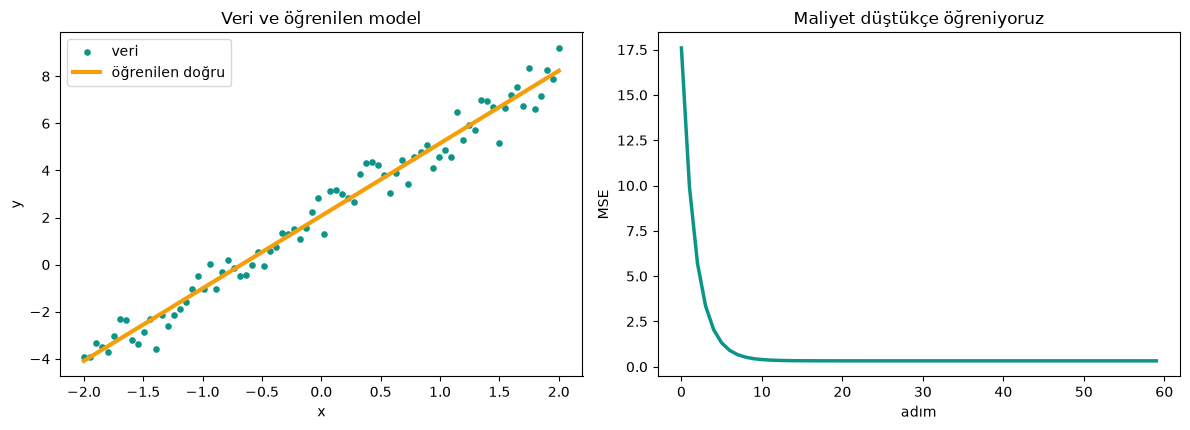

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sentetik veri: gerçek ilişki y = 3x + 2 + gürültü
rng = np.random.default_rng(0)
x = np.linspace(-2, 2, 80)
y = 3 * x + 2 + rng.normal(0, 0.6, size=x.shape)

w, b = 0.0, 0.0          # karanlık başlangıç: parametreler rastgele/sıfır
lr = 0.1
gecmis = []

for adim in range(60):
    tahmin = w * x + b
    hata = tahmin - y
    mse = np.mean(hata ** 2)
    gecmis.append(mse)
    grad_w = 2 * np.mean(hata * x)   # dMSE/dw — elle türev
    grad_b = 2 * np.mean(hata)       # dMSE/db — elle türev
    w -= lr * grad_w                 # GÜNCELLEME KURALI: tepeye karşı yürü
    b -= lr * grad_b
    if adim % 15 == 0:
        print(f"adım {adim:2d} | mse = {mse:8.4f} | w = {w:6.3f}, b = {b:6.3f}")

print()
print(f"Öğrenilen model : y = {w:.3f}x + {b:.3f}")
print(f"Gerçek ilişki   : y = 3.000x + 2.000")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(x, y, s=14, color="#0d9488", label="veri")
axes[0].plot(x, w * x + b, color="#f59e0b", lw=3, label="öğrenilen doğru")
axes[0].set_title("Veri ve öğrenilen model")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].legend()
axes[1].plot(gecmis, color="#0d9488", lw=2.5)
axes[1].set_title("Maliyet düştükçe öğreniyoruz")
axes[1].set_xlabel("adım"); axes[1].set_ylabel("MSE")
plt.tight_layout(); plt.show()

## 2 · Eğitimin Ritmi: Batch, Epoch ve Öğrenme Hızı

Gerçek veri setlerinde milyonlarca örnek vardır; hepsini her adımda kullanmak (tam batch) hem yavaş hem gereksizdir. Pratikte veri **mini-batch**'lere bölünür:

| Terim | Tanım | Örnek (500 örnek, batch = 100) |
|---|---|---|
| **Batch** | Bir güncelleme adımında kullanılan örnek grubu | 100 örnek → 1 güncelleme |
| **İterasyon** | 1 batch'in işlenmesi | 1 epoch'ta 5 iterasyon |
| **Epoch** | Tüm eğitim verisinin **bir tam geçişi** | 5 batch × 5 = veri 1 kez görüldü |

`lr` bu ritmin **adım boyudur**: küçük lr = hassas ama yavaş; büyük lr = hızlı ama minimumun üzerinden atlama riski. Üçü birlikte eğitimin "ritm bölümünü" oluşturur.

### Demo (c) — İlk modelimiz: `nn.Linear` + `SGD`

Artık modeli de PyTorch'a yazdırıyoruz. `nn.Linear(1, 1)` tam olarak $\hat{y} = wx + b$ demektir; `SGD` (stokastik gradyan inişi) yukarıda elle yazdığımız güncelleme kuralının kendisidir.

![Yapay sinir ağı (MLP) topolojisi — girdi, gizli ve çıkış katmanları](assets/v2-gorsel-02-mlp-yapisi.svg)

*Yapay sinir ağı (MLP): katmanlar, nöronlar ve ağırlık bağlantıları.*

Görselde üç katmanlı klasik bir ağ topolojisi: solda girdi katmanı, ortada gizli katman, sağda çıkış katmanı; her ok bir bağlantıyı, her bağlantı öğrenilecek bir ağırlığı taşır. Yukarıdaki Demo (c)'deki `nn.Linear(1, 1)` bu topolojinin en küçük hâlidir — tek girdi, tek nöron, tek ağırlık; gizli katmanlar eklendikçe ağa derinlik, aktifleştirmelerle birlikte doğrusal olmayanlık katılır. (Görsel: Wikimedia Commons — "Artificial neural network".)

### Arka plandaki matematik

`nn.Linear(1, 1)` tam olarak $\hat{y} = wx + b$ demektir: model tek ağırlık $w$ ve tek sapma $b$ tutar. `torch.optim.SGD` ise yukarıda elle yazdığımız güncelleme kuralının kendisidir, mini-batch'e uygulanmış hâliyle:

$$w \leftarrow w - \eta \cdot \frac{1}{B}\sum_{i \in \text{batch}} 2(\hat{y}_i - y_i)\,x_i$$

**Sayısal örnek (elle):** batch'te iki örnek $(x,y) = (1,3)$ ve $(2,5)$; $w=0.2,\ b=0$:
- Tahminler $(0.2,\ 0.4)$; hatalar $(-2.8,\ -4.6)$
- $\dfrac{\partial C}{\partial w} = \dfrac{2}{2}\left((-2.8)(1) + (-4.6)(2)\right) = -12.0$, $\dfrac{\partial C}{\partial b} = \dfrac{2}{2}(-2.8-4.6) = -7.4$
- lr $=0.1$: $w \leftarrow 0.2 + 1.2 = 1.4$, $b \leftarrow 0.74$. Tek batch tek küçük adım; 60 epoch $\times$ 8 batch = 480 adım işi bitirir.

> Bu blok, ilk PyTorch modeli hücresi için gerekli: döngünün her satırı (karıştır → batch seç → sıfırla → ileri → backward → step) yukarıdaki tek formülün parçalarıdır.

#### Satır satır
- `import torch` / `import torch.nn as nn` / `import matplotlib.pyplot as plt` → PyTorch çekirdeği, sinir ağı modülü (`nn`: hazır katman ve kayıp sınıfları) ve grafik aracı.
- `torch.manual_seed(42)` → rastgelelik tohumu: modelin başlangıç ağırlıkları her çalıştırmada aynı çıkar.
- `N = 120` → örnek sayısı.
- `X = torch.rand(N, 1) * 4 - 2` → $[0,1)$ aralığında 120 tek-sütunlu rastgele sayıyı $[-2,2)$ aralığına kaydırır. Neden: demo (a) ile aynı giriş aralığı.
- `Y = 3 * X + 2 + torch.randn(N, 1) * 0.6` → aynı $3x+2$ ilişkisi + gürültü, torch tensörü olarak.
- `model = nn.Linear(1, 1)` → model nesnesi: bir girdiden bir çıktıya, içinde `weight` ve `bias` parametreleri taşır. Neden: modeli artık PyTorch yönetir; gradyanlar ve parametreler standart yerlerde durur.
- `print(model)` → katmanın yapısını (`Linear(in_features=1, out_features=1)`) yazar.
- `print(f"rastgele başlangıç ...")` → rastgele başlangıç parametrelerini gösterir: öğrenmenin ne kadar ilerleyeceğini kıyaslamak için.
- `opt = torch.optim.SGD(model.parameters(), lr=0.1)` → SGD (stokastik gradyan inişi) optimize edicisi; `model.parameters()` ağırlıkları ona bağlar, `lr=0.1` adım boyu. Neden: elle `w -= lr*grad` yazma yerini `step()`'e bırakır.
- `kayip_fonk = nn.MSELoss()` → hazır MSE kayıp fonksiyonu; elle `np.mean(hata**2)` yazmaya gerek kalmadı.
- `BATCH, EPOCH = 16, 60` → batch boyutu 16, 60 tam tur.
- `kayip_egrisi = []` → her adımın kaybını tutar; alttaki grafik bunu çizer.
- `for epoch in range(EPOCH):` → dış döngü: verinin tam turları.
- `karisik = torch.randperm(N)` → 0..119 indekslerini her epoch'ta yeniden karıştırır. Neden: sıralı veri eğitimi yanlı yönlendirebilir; karıştırma batch'lerin veriyi temsil etmesini sağlar.
- `for i in range(0, N, BATCH):` → iç döngü: 16'şar adımlı batch başlangıç indeksleri (0, 16, 32, ...).
- `idx = karisik[i:i + BATCH]` → bu batch'e düşen örneklerin indeksleri.
- `xb, yb = X[idx], Y[idx]` → indeks listesiyle seçim (fancy indexing): batch'in girdileri ve hedefleri.
- `opt.zero_grad()` → gradyanları sıfırlar; önceki demoda `w.grad.zero_()` elle yapılıyordu, optimizer artık tüm parametreleri tek seferde sıfırlar.
- `kayip = kayip_fonk(model(xb), yb)` → ileri geçiş: model batch'e tahmin üretir, MSE hesaplanır.
- `kayip.backward()` → gradyanlar otomatik.
- `opt.step()` → güncelleme kuralını tüm parametrelere uygular.
- `kayip_egrisi.append(kayip.item())` → `.item()` tek-elemanlı tensörden Python sayısı çıkarır; kaydı eğri için saklar.
- print blokları → öğrenilen $w, b$ ile gerçek ilişkiyi kıyaslar; adım sayısını yazar (120 örnek, 16'lık batch'lerle epoch başına 8 adım — son batch kısa; 60 epoch $\times$ 8 = 480 adım).
- `plt.figure(...)` / `plt.plot(kayip_egrisi, ...)` / başlık ve eksen satırları / `plt.show()` → adım adım kayıp eğrisini çizer; düşen eğri eğitimin işe yaradığının görsel kanıtıdır.

Linear(in_features=1, out_features=1, bias=True)
rastgele başlangıç : w = 0.559, b = -0.696
eğitim sonrası      : w = 3.002, b = 1.999
gerçek ilişki       : w = 3.000, b = 2.000
toplam güncelleme   : 60 epoch x 7 batch = 480 adım
kayıp: 17.9924 -> 0.1355


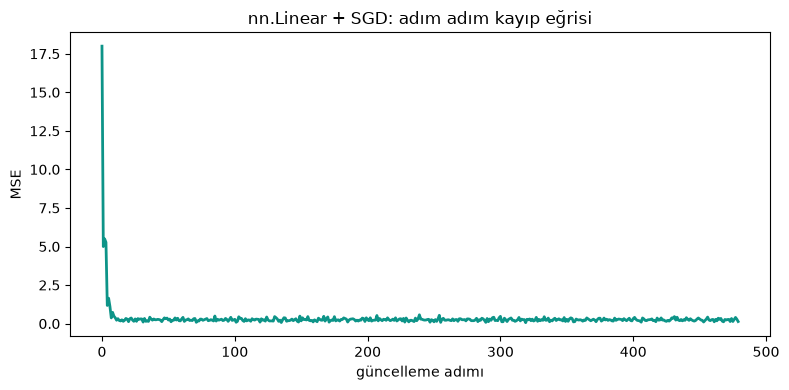

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Veri: demo (a) ile aynı ilişki, torch tensörü olarak
N = 120
X = torch.rand(N, 1) * 4 - 2
Y = 3 * X + 2 + torch.randn(N, 1) * 0.6

model = nn.Linear(1, 1)          # y = w*x + b
print(model)
print(f"rastgele başlangıç : w = {model.weight.item():.3f}, b = {model.bias.item():.3f}")

opt = torch.optim.SGD(model.parameters(), lr=0.1)
kayip_fonk = nn.MSELoss()

BATCH, EPOCH = 16, 60
kayip_egrisi = []

for epoch in range(EPOCH):
    karisik = torch.randperm(N)                  # her epoch'ta yeniden karıştır
    #print(f"Karisik:{karisik}")
    for i in range(0, N, BATCH):                 # mini-batch'ler
        idx = karisik[i:i + BATCH]
        xb, yb = X[idx], Y[idx]
        opt.zero_grad()
        predict = model(xb)
        kayip = kayip_fonk(predict, yb)        # ileri geçiş
        kayip.backward()                         # gradyanlar
        opt.step()                               # güncelleme
        kayip_egrisi.append(kayip.item())

print(f"eğitim sonrası      : w = {model.weight.item():.3f}, b = {model.bias.item():.3f}")
print(f"gerçek ilişki       : w = 3.000, b = 2.000")
print(f"toplam güncelleme   : {EPOCH} epoch x {N // BATCH} batch = {len(kayip_egrisi)} adım")
print(f"kayıp: {kayip_egrisi[0]:.4f} -> {kayip_egrisi[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(kayip_egrisi, color="#0d9488", lw=2)
plt.title("nn.Linear + SGD: adım adım kayıp eğrisi")
plt.xlabel("güncelleme adımı"); plt.ylabel("MSE")
plt.tight_layout(); 
plt.show()

In [6]:
X[karisik[0]]

tensor([-0.5647])

### Demo (d) — Öğrenme hızı deneyi: lr = 0.001 / 0.1 / 1.0

Aynı model, aynı veri, tek fark `lr`. Klipte gördüğümüz üç davranışı şimdi sayılarla görelim. Dikkat: `lr = 1.0` için kayıp **patlar** (sonsuz/NaN olur) — gradyan inişinin klasik kazası.

### Arka plandaki matematik (kısa)

Deney tek soruya cevap arar: güncelleme kuralındaki $w \leftarrow w - \text{lr}\cdot\frac{\partial C}{\partial w}$ çarpanı sonucu nasıl değiştirir? **Sayısal örnek (elle):** $w = 1$ ve gradyan $\frac{\partial C}{\partial w} = 6$ için:
- lr $=0.001$: $w \leftarrow 1 - 0.006 = 0.994$ — neredeyse yerinde sayar
- lr $=0.1$: $w \leftarrow 1 - 0.6 = 0.4$ — sağlıklı adım
- lr $=1.0$: $w \leftarrow 1 - 6 = -5$ — minimumu geçer, karşı tepeye fırlar; kayıp her adımda büyür ve **patlar** (NaN)

> Bu blok, lr deneyi hücresi için gerekli: grafikteki üç davranışın (yavaş, dengeli, patlama) tek bir çarpım katsayısından doğduğunu sayılarla görürüz.

#### Satır satır
- `import torch` / `import torch.nn as nn` / `import matplotlib.pyplot as plt` → aynı üç araç: tensör, ağ parçaları, grafik.
- `torch.manual_seed(42)` → tekrarlanabilirlik için tohum.
- `N = 120`, `X = ...`, `Y = ...`, `kayip_fonk = nn.MSELoss()` → demo (c) ile birebir aynı veri ve kayıp; deneyde tek değişken lr olsun.
- `def egit(lr, adim=300):` → eğitimi fonksiyona sarar: aynı kurulumu farklı lr'lerle tekrar tekrar çalıştırabilmek için.
- `torch.manual_seed(0)` / `model = nn.Linear(1, 1)` / `opt = torch.optim.SGD(..., lr=lr)` → her denemede aynı başlangıç ağırlıkları, denenen lr ile taze model. Neden: farkı yalnız lr belirsin (adil deney).
- `for _ in range(adim):` → 300 tam-batch adımı (tüm 120 örnek tek hesapta; deneyi sade tutmak için).
- `opt.zero_grad()` → gradyan birikimini sıfırla; `kayip = kayip_fonk(model(X), Y)` → ileri geçiş; `kayip.backward()` → gradyanlar; `opt.step()` → güncelleme.
- `kayiplar.append(kayip.item())` → kayıp geçmişi.
- `return kayiplar, model.weight.item(), model.bias.item()` → eğri ve son parametreleri çağırana döndürür.
- `renkler = {...}` → her lr'ye bir renk: grafikte üç eğriyi ayırt etmek için.
- `for lr in [0.001, 0.1, 1.0]:` → üç deney tek döngüde.
- `if kayiplar[-1] > 1e6 or kayiplar[-1] != kayiplar[-1]:` → patlama teşhisi: son kayıp devasa ya da NaN ise (NaN kendine eşit değildir) etikete "(patladı)" eklenir. Neden: NaN grafikte boşluk olarak görünür; açık yazı daha öğretici.
- `plt.yscale("log")` → dikey ekseni logaritmik yapar. Neden: 0.001 mertebesinde ve milyon mertebesinde kayıplar aynı grafikte görülebilir olsun.
- kalan satırlar → başlık, eksen etiketleri, gösterge (`legend`) ve `plt.show()` ile şekli ekrana basma.

Baslangic Weight: -0.007486820220947266 bias:0.5364435911178589
Bitis Weight: 3.0016770362854004 bias:1.9987168312072754
lr = 0.001  | son kayıp =       3.2461 | w =      1.658, b =      1.131
Baslangic Weight: -0.007486820220947266 bias:0.5364435911178589
Bitis Weight: 3.0016770362854004 bias:1.9987168312072754
lr = 0.1    | son kayıp =       0.2446 | w =      2.971, b =      1.976
Baslangic Weight: -0.007486820220947266 bias:0.5364435911178589
Bitis Weight: 3.0016770362854004 bias:1.9987168312072754
lr = 1.0    | son kayıp =          nan | w =        nan, b =        nan


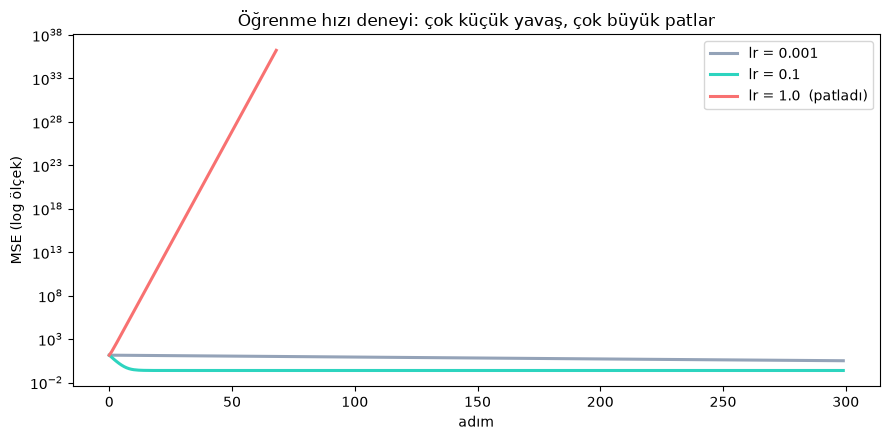

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
N = 120
X = torch.rand(N, 1) * 4 - 2
Y = 3 * X + 2 + torch.randn(N, 1) * 0.6
kayip_fonk = nn.MSELoss()

def egit(lr, adim=300):
    torch.manual_seed(0)
    model = nn.Linear(1, 1) # Wx+b
    print(f"Baslangic Weight: {model.weight.item()} bias:{model.bias.item()}")
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    kayiplar = []
    for _ in range(adim):
        opt.zero_grad()
        kayip = kayip_fonk(model(X), Y)
        kayip.backward() # gradyanlari hesapla dL/dw , dL/db
        opt.step() # weight ve bias degerlerini guncelle
        kayiplar.append(kayip.item())
    return kayiplar, model.weight.item(), model.bias.item()

renkler = {"0.001": "#94a3b8", "0.1": "#2dd4bf", "1.0": "#f87171"}
plt.figure(figsize=(9, 4.5))
for lr in [0.001, 0.1, 1.0]:
    kayiplar, w, b = egit(lr)
    print(f"Bitis Weight: {model.weight.item()} bias:{model.bias.item()}")
    etiket = f"lr = {lr}"
    if kayiplar[-1] > 1e6 or kayiplar[-1] != kayiplar[-1]:
        etiket += "  (patladı)"
    print(f"lr = {lr:<6} | son kayıp = {kayiplar[-1]:12.4f} | w = {w:10.3f}, b = {b:10.3f}")
    plt.plot(kayiplar, color=renkler[str(lr)], lw=2.2, label=etiket)

plt.yscale("log")
plt.title("Öğrenme hızı deneyi: çok küçük yavaş, çok büyük patlar")
plt.xlabel("adım"); plt.ylabel("MSE (log ölçek)")
plt.legend(); plt.tight_layout(); plt.show()

### Demo (e) — Aktivasyon fonksiyonları: nöronun esnekliği

Şimdiye kadar kurduğumuz her şey **doğrusaldi**: `nn.Linear` katmanlarını üst üste koysak da sonuç tek bir düz çizgi olurdu. Derin ağları güçlü kılan, katman aralarına konan **aktivasyon fonksiyonları** — doğrusal olmayan bükümler:

| Fonksiyon | Formül | Karakteri |
|---|---|---|
| **sigmoid** | $\sigma(z) = 1/(1+e^{-z})$ | Çıktı $(0, 1)$ — olasılık gibi; doyar |
| **tanh** | $\tanh(z)$ | Çıktı $(-1, 1)$ — sıfır merkezli; doyar |
| **ReLU** | $\max(0, z)$ | Negatifse 0, değilse kendisi — basit ve hızlı; günümüzün varsayılanı |


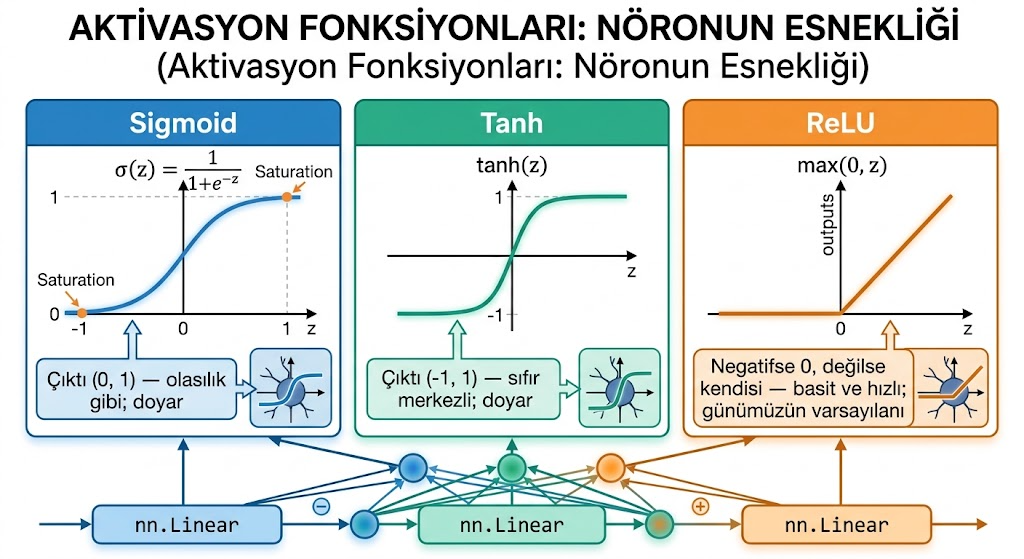

### Arka plandaki matematik

Üç klasik aktivasyonun formülleri ve $z=1$ noktasındaki değerleri (elle):
- sigmoid: $\sigma(z) = \dfrac{1}{1+e^{-z}}$ → $\sigma(1) = \dfrac{1}{1+0.3679} = 0.731$; türevi $\sigma'(z) = \sigma(z)\,(1-\sigma(z))$ → $0.731 \times 0.269 = 0.197$
- tanh: $\tanh(1) = 0.762$; türevi $1 - \tanh^2(z)$ → $1 - 0.580 = 0.420$
- ReLU: $\max(0, z)$ → $\max(0,1) = 1$; türevi $z>0$ iken $1$, $z<0$ iken $0$

**Doğrusallık tuzağının kanıtı:** aktivasyonsuz iki katman $\hat{y} = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)\,x + (W_2 b_1 + b_2)$ — yani tek bir doğrusal model. Sayısal örnek: $W_1 = \begin{bmatrix} 2 & 0 \\ 0 & 3 \end{bmatrix}$, $W_2 = \begin{bmatrix} 1 & 1 \end{bmatrix}$ → $W_2 W_1 = \begin{bmatrix} 2 & 3 \end{bmatrix}$; iki katmanlı ağ, tek satırlık $y = 2x_1 + 3x_2$'den öteye geçemez.

> Bu blok, aktivasyon hücresi için gerekli: formülsüz grafik sadece güzel eğri; sayısal değerler ve $W_2W_1$ çarpımı, "neden büküm şart" sorusunu cevaplar.

#### Satır satır
- `import torch` / `import matplotlib.pyplot as plt` → tensör ve grafik araçları. (Hücre `nn.Linear` kullanır; `nn` adı önceki hücrelerde `import torch.nn as nn` ile tanımlandığı için burada tekrar gerekmez.)
- `z = torch.linspace(-6, 6, 400)` → $-6$ ile $6$ arasında 400 nokta: eğrilerin çizileceği yatay eksen.
- `fonksiyonlar = [ (torch.sigmoid, ...), ... ]` → üçlü demetler: (fonksiyon, ad, kısa açıklama). Neden: üç paneli aynı döngüyle, tekrarsız kodla çizmek.
- `fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)` → yan yana üç panel; `sharey=True` dikey ekseni ortaklar, böylece üç eğrinin değer aralığı adil kıyaslanır.
- `for ax, (fn, ad, aciklama) in zip(axes, fonksiyonlar):` → `zip` panellerle üçlüleri eşler; her panel kendi fonksiyonunu çizer.
- `ax.plot(z, fn(z), ...)` → o panelin aktivasyon eğrisini çizer.
- `ax.axhline(0, ...)` / `ax.axvline(0, ...)` → yatay ve dikey sıfır çizgileri: fonksiyonun işaret değişimi ve merkezini görsel referans olarak gösterir.
- `ax.set_title(ad, fontsize=13)` / `ax.set_xlabel("z")` → panel başlığı ve x ekseni etiketi.
- `ax.text(0.5, 0.06, aciklama, transform=ax.transAxes, ...)` → panelin altına açıklama yazar; `transform=ax.transAxes` koordinatları 0-1 aralığına ölçekler (0.5 = panelin ortası, 0.06 = dibe yakın).
- `axes[0].set_ylabel("çıkış")` → yalnız en soldaki panele y etiketi (paneler dikey ekseni paylaştığı için yeterli).
- `plt.suptitle(...)` → üç panelin üstüne ortak başlık; `plt.tight_layout(); plt.show()` → düzenle ve ekrana bas.
- `torch.manual_seed(0)` → kanıt bölümü için tohum.
- `katman1 = nn.Linear(2, 8)` / `katman2 = nn.Linear(8, 2)` → aktivasyonsuz ardışık iki doğrusal katman.
- `girdi = torch.randn(5, 2)` → 5 örneklik rastgele test girdisi.
- `ust_uste = katman2(katman1(girdi))` → aktivasyonsuz iki katmanın bileşimi.
- `tek_katman = nn.Linear(2, 2)` → kıyaslama için tek doğrusal katman.
- `tek_katman.weight.copy_(katman2.weight @ katman1.weight)` → ağırlığı $W_2 W_1$'e (matris çarpımı `@`) eşitler. Neden: iki doğrusal dönüşümün bileşiminin tek matris olduğunu sayısal olarak kanıtlamak.
- `tek_katman.bias.copy_(katman2.bias + katman2.weight @ katman1.bias)` → eşdeğer sapma: $b_2 + W_2 b_1$.
- `fark = (ust_uste - tek_katman(girdi)).abs().max().item()` → iki sonucun en büyük mutlak farkı; $\approx 0$ çıkışı "iki katman = tek katman" iddiasının kanıtı.
- son print blokları → farkı ve sonucu yazar: aktivasyon olmadan derinlik güç katmaz.

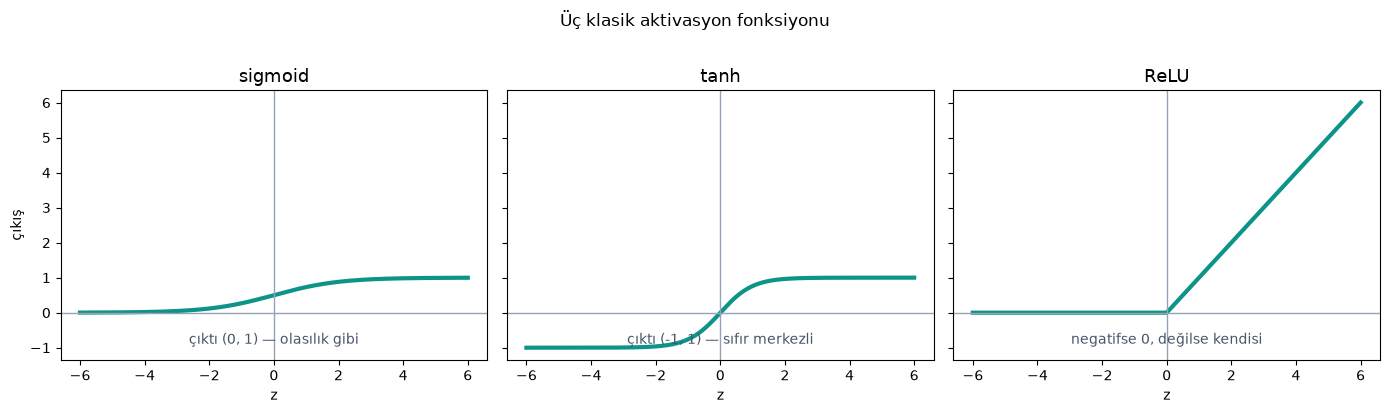

iki lineer katman üst üste ≈ tek lineer katman  (maks fark = 5.96e-08)
Sonuç: aktivasyon olmadan derinlik güç katmaz — büküm (aktivasyon) şart.


In [31]:
import torch
import matplotlib.pyplot as plt

z = torch.linspace(-6, 6, 400)
fonksiyonlar = [
    (torch.sigmoid, "sigmoid", "çıktı (0, 1) — olasılık gibi"),
    (torch.tanh,    "tanh",    "çıktı (-1, 1) — sıfır merkezli"),
    (torch.relu,    "ReLU",    "negatifse 0, değilse kendisi"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (fn, ad, aciklama) in zip(axes, fonksiyonlar):
    ax.plot(z, fn(z), color="#0d9488", lw=3)
    ax.axhline(0, color="#94a3b8", lw=1)
    ax.axvline(0, color="#94a3b8", lw=1)
    ax.set_title(ad, fontsize=13)
    ax.set_xlabel("z")
    ax.text(0.5, 0.06, aciklama, transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
axes[0].set_ylabel("çıkış")
plt.suptitle("Üç klasik aktivasyon fonksiyonu", y=1.02)
plt.tight_layout(); plt.show()

# Doğrusallık tuzağının kanıtı: aktivasyonsuz derinlik = tek lineer katman
torch.manual_seed(0)
katman1 = nn.Linear(2, 8)
katman2 = nn.Linear(8, 2)
girdi = torch.randn(5, 2)

ust_uste = katman2(katman1(girdi))                    # aktivasyonsuz iki katman
tek_katman = nn.Linear(2, 2)
with torch.no_grad():
    tek_katman.weight.copy_(katman2.weight @ katman1.weight)  # W2 @ W1
    tek_katman.bias.copy_(katman2.bias + katman2.weight @ katman1.bias)

fark = (ust_uste - tek_katman(girdi)).abs().max().item()
print(f"iki lineer katman üst üste ≈ tek lineer katman  (maks fark = {fark:.2e})")
print("Sonuç: aktivasyon olmadan derinlik güç katmaz — büküm (aktivasyon) şart.")

## Bölüm Sonu Uygulaması: Model Nereye Bakıyor — Tek Nöronla 0/1 Rakam Ayrımı

Öğrendiğimiz her parçayı bir gerçek görüntü görevinde birleştiriyoruz: 8×8 rakamlardan yalnızca **0** ve **1** sınıflarını alıp **tek bir nöronla** ayıracağız. Nöron, 64 pikselin her birine bir ağırlık verir ve katkıları toplar:

$$z = w_1 p_1 + w_2 p_2 + \cdots + w_{64} p_{64} + b$$

Eğitim bittiğinde bu 64 ağırlığı **8×8 ısı haritası** olarak çizersek modelin "bakışı" görünür olur: hangi piksel "1" oyunu, hangi piksel "0" oyunu vermiş? İşte uygulamanın somut çıktısı tam bu resimdir: **model nereye bakıyor?**

> **Neden bu uygulama?** Gradyan inişini 64 parametreli gerçekten görüntü verisi üzerinde çalıştırmak ve modelin kararını verirken neye güvendiğini tek bir resimle görmek; hepsi CPU'da saniyeler içinde çalışır.

### Arka plandaki matematik

Tek nöron iki adımda karar verir. Önce **özet** (piksellerin ağırlıklı toplamı):

$$z = \sum_{j=1}^{64} w_j\,p_j + b \qquad (p_j: 8 \times 8\text{'lik tablonun düzleştirilmiş } j\text{. pikseli})$$

Sonra **karar olasılığı**: sigmoid $\hat{y} = \sigma(z) = \dfrac{1}{1+e^{-z}}$ — her sayıyı $(0,1)$ aralığına büker; $\hat{y} > 0.5$ ise "1", değilse "0" deriz. Kayıp bu kez **ikili çapraz entropi (BCE)**:

$$C = -\left[y\ln\hat{y} + (1-y)\ln(1-\hat{y})\right]$$

Kabul edilmesi gereken zarafet: sigmoid + BCE'nin **z'ye göre türevi** basitçe $\left(\hat{y} - y\right)$ çıkar; dolayısıyla ağırlık başına gradyan:

$$\frac{\partial C}{\partial w_j} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)\,p_{ij}$$

(MSE'deki $2$ katsayısı yok — sigmoid'in türevi, BCE'nin türevini tam yumuşatıyor.)

**Sayısal örnek (elle):** tek örneğe bakalım: $(p_1, p_2) = (2, 0)$, hedefi $y = 1$; başlangıç $w_1 = w_2 = b = 0$:
- $z = 0$ → $\hat{y} = 0.5$; kayıp $= -\ln 0.5 = 0.69$
- $\dfrac{\partial C}{\partial w_1} = (\hat{y}-y)\,p_1 = (-0.5)(2) = -1$; $\dfrac{\partial C}{\partial w_2} = 0$; $\dfrac{\partial C}{\partial b} = -0.5$
- lr $=0.1$: $w_1 \leftarrow 0 - 0.1(-1) = 0.1$ — model tek adımda "1. piksel parlaksa rakam 1'dir" oyusunu verdi.

Ağırlığın **işareti** pikselin hangi rakamı desteklediğini söyler: pozitif ağırlıklı piksel parlaksa model "1" tarafına, negatif ağırlıklı piksel parlaksa "0" tarafına basar; ısı haritasında bu kırmızı/mavi bölgeler olarak görünür.

In [32]:
try:
    from sklearn.datasets import load_digits
    v_, h_ = load_digits(return_X_y=True)
    sec = (h_ == 0) | (h_ == 1)                     # yalnızca 0 ve 1 örnekleri
    X, rakamsayi = v_[sec] / 16.0, h_[sec].astype(float)   # pikseller 0-16 -> 0-1 aralığına
    kaynak = "sklearn digits"
except Exception as hata:
    print(f"sklearn yok ({hata.__class__.__name__}) -> sentetik örüntüler kullanılıyor")
    g, t = sentetik_rakamlar(60)                    # Ana Veri bölümünde tanımlıydı
    X, rakamsayi = g.reshape(len(g), -1) / 16.0, t.astype(float)
    kaynak = "sentetik (halka = 0, çubuk = 1)"

sira = np.random.default_rng(0).permutation(len(X))   # tohumlu karıştırma
X, rakamsayi = X[sira], rakamsayi[sira]; bol = int(0.8 * len(X))  # karıştır + %80/%20 bölme
Xegit, Xtest, yegit, ytest = X[:bol], X[bol:], rakamsayi[:bol], rakamsayi[bol:]
print(f"kaynak={kaynak} | {len(Xegit)} eğitim, {len(Xtest)} test örnek | piksel: {Xegit.shape[1]}")

kaynak=sklearn digits | 288 eğitim, 72 test örnek | piksel: 64


In [33]:
# Tek nöronun eğitimi: z = w·x + b -> sigmoid; kayıp BCE; gradyanlar ELLE (numpy)
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))  # clip: exp taşmasını önleyen güvenlik -30 ile 30 arasina sikistirir.

rng = np.random.default_rng(0); 
w = rng.normal(0, 0.1, size=64)  # 64 piksele küçük rastgele ağırlık
b, lr, adim_sayisi = 0.0, 0.5, 300              # sapma, adım boyu ve adım sayısı (saniyeler sürer)

for adim in range(adim_sayisi):
    tahmin = sigmoid(Xegit @ w + b)             # olasılık tahmini: tüm örnekler tek çarpımda
    hata = tahmin - yegit                       # (sigmoid+BCE): gradyanın özü tahmin - gerçek
    grad_w = (Xegit.T @ hata) / len(yegit)      # ∂C/∂w = (1/N) Σ (tahmin-y)·piksel — tek satırda
    grad_b = hata.mean()                        # ∂C/∂b = (1/N) Σ (tahmin-y)
    w -= lr * grad_w                            # GÜNCELLEME: gradyanın tersine küçük adım
    b -= lr * grad_b
    kayip = -np.mean(yegit*np.log(tahmin) + (1-yegit)*np.log(1-tahmin))
    if adim % 50 == 0:                          # her 50 adımda ara rapor
        print(f"adım {adim:3d} | BCE kaybı = {kayip:.4f}")

adım   0 | BCE kaybı = 0.7576
adım  50 | BCE kaybı = 0.0374
adım 100 | BCE kaybı = 0.0213
adım 150 | BCE kaybı = 0.0154
adım 200 | BCE kaybı = 0.0122
adım 250 | BCE kaybı = 0.0101


In [34]:
# Eğitim bitti: test kümesinde nöronun kararı ne kadar doğru?
tahmin_test = sigmoid(Xtest @ w + b)            # test örnekleri için olasılıklar
sayisal = (tahmin_test >= 0.5).astype(float)    # olasılık ≥ 0.5 -> "1" deriz
dogru = int((sayisal == ytest).sum())           # doğru sınıflama sayacı
print(f"son BCE kaybı (test): {-np.mean(ytest*np.log(tahmin_test) + (1-ytest)*np.log(1-tahmin_test)):.4f}")
print(f"test doğruluğu: {dogru}/{len(ytest)} = {100 * dogru / len(ytest):.1f}% (eşik: olasılık ≥ 0.5 -> '1')")

# not: 8x8 rakamlarda 0 ile 1 doğrusal olarak AYRILABİLİR bir problemdir — tek nöron bile
# %100'e ulaşır; 10 sınıf rakam için gizli katmanlar şart (detay: Oturum 03)

son BCE kaybı (test): 0.0206
test doğruluğu: 72/72 = 100.0% (eşik: olasılık ≥ 0.5 -> '1')


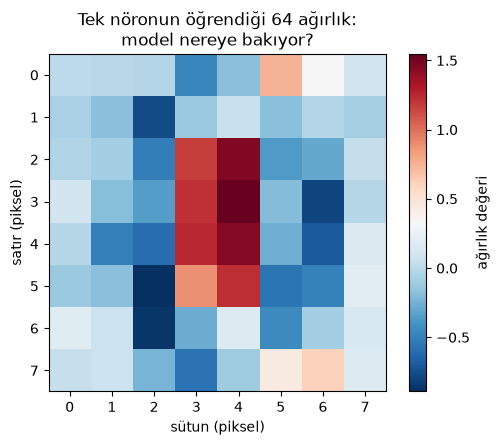

en pozitif ağırlık: +1.547 | en negatif: -0.891
okuma rehberi: 1 rakamının parlak dikey çubuğu ortada -> orta bölge kırmızıya boyanır;
0 rakamının halkası kenarlara yayılır -> kenar pikselleri maviye eğilimlidir.


In [35]:
# Somut çıktı: 64 ağırlığı 8x8 tabloya geri açalım — modelin bakış haritası
import matplotlib.pyplot as plt
bakis = w.reshape(8, 8)   # 64 ağırlık piksel düzlemine geri açılır (8 satır x 8 sütun)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(bakis, cmap="RdBu_r")   # kırmızı = pozitif ağırlık ('1' oyu), mavi = negatif ('0' oyu)
plt.colorbar(label="ağırlık değeri")
plt.title("Tek nöronun öğrendiği 64 ağırlık:\nmodel nereye bakıyor?")
plt.xlabel("sütun (piksel)"); plt.ylabel("satır (piksel)")
plt.tight_layout(); plt.show()

print(f"en pozitif ağırlık: {bakis.max():+.3f} | en negatif: {bakis.min():+.3f}")
print("okuma rehberi: 1 rakamının parlak dikey çubuğu ortada -> orta bölge kırmızıya boyanır;")
print("0 rakamının halkası kenarlara yayılır -> kenar pikselleri maviye eğilimlidir.")

## Mini Quiz

1. Maliyet (kayıp) fonksiyonu neyi **tek bir sayıya** indirger? MSE formülünü yazınız.
2. Gradyan inişinde neden gradyanın **negatif** yönünde yürürüz?
3. 500 örnekli veri setinde batch boyutu 100 ise **1 epoch** kaç güncelleme adımıdır?
4. `lr = 0.0000001` ile eğitim başlatırsanız ne olur? `lr = 1000` ile?
5. `torch.autograd` bize hangi zahmetten kurtarır? Demo (a) ile (b) arasındaki farkı bir cümleyle açıklayınız.
6. Aktivasyon fonksiyonu olmayan 10 katmanlı bir ağ neden 1 katmanlı ağdan farklı değildir?

### Cevaplar

<details><summary>Açmak için tıkla</summary>

1. Modelin tüm eğitim verisi üzerindeki toplam yanlışlığını. $C = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$.
2. Gradyan, maliyetin **en hızlı arttığı** yönü gösterir; azaltmak için tersi (iniş) yönünde adım atarız: $w \leftarrow w - \eta \cdot \partial C/\partial w$.
3. $500 / 100 = 5$ güncelleme adımı (5 iterasyon).
4. Çok küçük lr: adımlar minicik, yakınsama dakikalar/saatler sürer. Çok büyük lr: minimumun üzerinden atlar, kayıp salınır ve tipik olarak **patlar** (NaN).
5. Türevleri elle yazma zahmeti. Demo (a)'da gradyan formülünü kendimiz kodladık; demo (b)'de yalnızca ileri hesabı kurup `backward()` dedik — gradyanlar otomatik geldi ve sonuç birebir aynı çıktı.
6. Ardışık lineer dönüşümlerin bileşimi yine lineerdir ($W_2(W_1x) = (W_2W_1)x$). Demo (e)'de bunun sayısal kanıtı var: iki katman tek katmana indirgendi.

</details>

---

## Özet

- **Maliyet fonksiyonu** yanlışlığı tek sayıya indirger; doğrusal modellerde $C(w)$ U şeklindedir.
- **Gradyan inişi** = eğimi hesapla, negatif yönde $\eta$ adımı at, tekrarla.
- **autograd** bu türevleri otomatik üretir: ileri hesabı kur, `backward()` çağır, `grad`'ı oku.
- **Batch** = güncelleme başına örnek grubu, **epoch** = tüm verinin tam geçişi, **lr** = adım boyu.
- Aktivasyon fonksiyonları ağa **doğrusal olmayanlık** katar; onlar olmadan derinlik güç değildir.

**Sonraki oturum:** Görüntü verisinin dünyasına giriyoruz — piksel matrisleri, RGB→HSV dönüşümleri, filtreler (blur, kenar) ve OpenCV ile ön işleme.

## Kaynakça

- PyTorch — Automatic Differentiation (`autograd`): <https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html>
- PyTorch — Optimization (model eğitimi resmî rehber): <https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html>
- 3Blue1Brown — Gradient descent (görsel anlatım): <https://www.3blue1brown.com/topics/neural-networks>
- Goodfellow, Bengio, Courville — *Deep Learning*, Böl. 8 (ücretsiz): <https://www.deeplearningbook.org>

## Kodlama Soruları

Bu oturumun kodları üzerinden 4 soru. Her biri küçük bir kodlama görevi; önce kendiniz yazmayı deneyin, sonra çözüm fikrine bakın.

### Soru 1 — Numpy ile elle bir gradyan inişi adımı

Tek örnekle elle bir adım atın: $x=2.0$, gerçek $y=6.0$ (hedef ilişki $y=3x$), başlangıç $w=0.0,\ b=0.0$, $\text{lr}=0.1$. MSE'yi, $\frac{\partial C}{\partial w}$ ve $\frac{\partial C}{\partial b}$'yi elle formülle hesaplayıp güncellenmiş $w$ ve $b$'yi yazdıran numpy kodu yazın. Beklenen çıktıyı önce elle hesaplayın.

<details><summary>Çözüm fikri</summary>

Elle: tahmin $\hat{y} = 0$; hata $= -6$; $\frac{\partial C}{\partial w} = 2\cdot(-6)\cdot 2 = -24$; $\frac{\partial C}{\partial b} = -12$. Güncelleme: $w \leftarrow 0 - 0.1\times(-24) = 2.4$, $b \leftarrow 1.2$.

```python
import numpy as np
x, y = np.array([2.0]), np.array([6.0])
w, b, lr = 0.0, 0.0, 0.1
tahmin = w * x + b
hata = tahmin - y
grad_w = 2 * np.mean(hata * x)
grad_b = 2 * np.mean(hata)
w -= lr * grad_w
b -= lr * grad_b
print(w, b)   # 2.4 1.2
```

Tek adımda tahmin $2.4\times 2 = 4.8$ — $6$'ya yaklaştı; adımlar tekrarlandıkça $w \to 3$, $b \to 0$.

</details>

### Soru 2 — Öğrenme hızı deneyini elle tekrarlamak

Demo (a)'daki kodu kopyalayıp `lr`'yi sırayla $0.001,\ 0.01,\ 0.1,\ 0.5,\ 1.0$ yaparak 60 adımın sonunda MSE'yi ve öğrenilen modeli yazdırın. Hangi lr en iyi $w \approx 3,\ b \approx 2$'ye ulaştı? Hangisi tıkandı, hangisi dalgalandı/patladı?

<details><summary>Çözüm fikri</summary>

```python
for lr in [0.001, 0.01, 0.1, 0.5, 1.0]:
    w, b = 0.0, 0.0
    for adim in range(60):
        hata = w * x + b - y
        w -= lr * 2 * np.mean(hata * x)
        b -= lr * 2 * np.mean(hata)
    print(lr, np.mean((w*x + b - y)**2), w, b)
```

Beklenen: `lr=0.001` 60 adımda neredeyse hiç ilerlemez (MSE hâlâ yüksek); `lr=0.1` dengeli, $w\approx 3$'e ulaşır; `lr=0.5` daha hızlı düşer ama kayıp salınabilir; `lr=1.0` bu veride minimumun üzerinden atlar, kayıp salınır ve büyüyerek patlar. Bu eğrinin eğriliği (Hessen matrisinin en büyük özdeğeri) $\approx 2.7$ olduğundan, $w \leftarrow w - \eta\,\nabla C$ kuralının yakınsaması için $\eta < 2/2.7 \approx 0.75$ gerekir — lr $=1.0$ bu barajın üstündedir.

</details>

### Soru 3 — XOR'u AND mimarisiyle çözememek

AND örneğindeki tek nöronlu mimariyi ($z = w_1x_1 + w_2x_2 + b$, sigmoid çıkış, MSE) şimdi **XOR** tablosuna eğitin: girdiler $(0,0),(0,1),(1,0),(1,1)$; hedefler $0,1,1,0$. lr $=0.5$ ile 2000 adım eğitin; ortalama kaybı ve dört tahmini yazdırın. Kayıp neden $\approx 0.25$ civarında takılır, düşmez?

<details><summary>Çözüm fikri</summary>

```python
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([0.,1.,1.,0.])
w = torch.tensor([0.5, 0.5], requires_grad=True)
b = torch.tensor(-0.7, requires_grad=True)
for adim in range(2000):
    a = torch.sigmoid(X @ w + b)
    L = torch.mean((a - Y)**2)
    L.backward()
    with torch.no_grad():
        w -= 0.5 * w.grad; b -= 0.5 * b.grad
    w.grad.zero_(); b.grad.zero_()
print(a.detach(), L.item())
```

Neden çözülmez: XOR'un $1$'leri (köşegen karşılıklı $(0,1)$ ve $(1,0)$) tek bir düz çizgiyle $0$'lardan ayrılamaz — doğrusal ayrılamaz bir problemdir. Tek nöron, ister sigmoid ister başka aktivasyon olsun, karar sınırı olarak tek bir düzlem üretir; en iyisi tüm çıkışları $0.5$'te dengelemektir ve o zaman MSE $= (0.5)^2 = 0.25$ olur. Gradyan inişi tam bu dengeye oturur. Çözüm için gizli katman + aktivasyon gerekir (önümüzdeki oturumların konusu).

</details>

### Soru 4 — Aktivasyon türevlerini autograd ile doğrulamak

$z = 1.0$ noktasında sigmoid ve tanh türevlerini elle hesaplayın ($\sigma'(z) = \sigma(z)(1-\sigma(z))$, $\tanh'(z) = 1 - \tanh^2(z)$). Sonra autograd ile doğrulayın: `x = torch.tensor(1.0, requires_grad=True)` üzerine `torch.sigmoid(x).backward()` çağırıp `x.grad`'i yazdırın; tanh için aynısını yapın. Elle bulduğunuz $0.197$ ve $0.420$ değerleriyle eşleşiyorlar mı?

<details><summary>Çözüm fikri</summary>

Elle: $\sigma(1) = 0.7311$ → $\sigma'(1) = 0.7311 \times 0.2689 = 0.1966$. $\tanh(1) = 0.7616$ → $\tanh'(1) = 1 - 0.5800 = 0.4200$.

```python
x = torch.tensor(1.0, requires_grad=True)
torch.sigmoid(x).backward()
print(x.grad.item())    # 0.19661161

y = torch.tensor(1.0, requires_grad=True)
torch.tanh(y).backward()
print(y.grad.item())    # 0.41997434
```

Not: her tensör için gradyan birikmesin diye yeni tensörler kullanın ya da arada `.grad.zero_()` çağırın — gradyanların birikme kuralı burada da geçerli.

</details>

### Soru 5 — AND nöronunu autograd ile eğitmek

AND kapısı örneğini autograd'a yaptırın: dört girdi çifti, hedefler $(0,0,0,1)$, sigmoid çıkış, MSE kaybı, lr $=0.5$, 1000 tam-batch adım, başlangıç $w_1=w_2=0.5,\ b=-0.7$. Son kaybı ve dört tahmini yazdırın. $(1,1)$ için tahmin $0.9$'un üstüne çıktı mı — nöron AND'i öğrendi mi?

<details><summary>Çözüm fikri</summary>

```python
import torch
torch.manual_seed(0)
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([0.,0.,0.,1.])
w = torch.tensor([0.5, 0.5], requires_grad=True)
b = torch.tensor(-0.7, requires_grad=True)
for adim in range(1000):
    a = torch.sigmoid(X @ w + b)
    L = torch.mean((a - Y)**2)
    L.backward()
    with torch.no_grad():
        w -= 0.5 * w.grad
        b -= 0.5 * b.grad
    w.grad.zero_(); b.grad.zero_()
print(a.detach().numpy().round(3), L.item())
```

Beklenen: kayıp $\approx 0.01$-$0.02$'ye düşer; tahminler yaklaşık $(0.05,\ 0.05,\ 0.05,\ 0.95)$ — $(1,1)$ için $0.9$'un üstünde. İlk adımdaki elle hesabımızda kayıp $0.1811 \rightarrow 0.1236$ düşmüştü; 1000 adım bu inisi tamamlayıp AND'i öğrenir. İsterseniz aynı eğitimi MSE yerine BCE kaybıyla ($-\left[y\ln a + (1-y)\ln(1-a)\right]$) tekrarlayıp yakınsama hızını kıyaslayabilirsiniz.

</details>

---

**Çözümlerde kullanılan kavramların özeti:** maliyet tek sayıdır; güncelleme kuralı $w \leftarrow w - \text{lr}\cdot\frac{\partial C}{\partial w}$; zincir kuralı türevleri çarpımlara söker; autograd bu türevleri işlem grafiğinden otomatik üretir; aktivasyonsuz derinlik tek doğrusal modele iner.

## Derinleşme — ders sonrası okuma

Ana akış herkesin ortak yoludur; aşağıdaki içerikler merak edenler için derinlestirici eklerdir:

- **AND kapısını tek nöronla elle eğitmek:** güncelleme kuralının gerçekten kaybı düşürdüğünün sayısal kanıtı.
- **`torch.autograd`:** elle yazdığımız türevi otomatik üretme — *detay: **Oturum 03**'ün konusudur*; burada erken merak edenler için.

**XOR neden tek nöronla çözülemez?** Tek cümleyle: XOR'un iki "1"i köşegenin karşılıklı ucunda durur ve hiçbir düz çizgi bu ikisini 0'lardan ayıramaz — tek nöronun karar sınırı her zaman düz bir çizgidir; çözüm için **gizli katman** şarttır (detay: Oturum 03).

### Arka plandaki matematik — AND kapısı örneği: tek nöronlu ağ, adım adım elle

Bu oturumun tüm fikrini **en küçük ağ** üzerinde sayı sayı yapalım: tek nöron, iki girdi. Mimari ve kayıp:

$$z = w_1 x_1 + w_2 x_2 + b, \qquad a = \sigma(z) = \frac{1}{1+e^{-z}}, \qquad L = (a - y)^2 \;(\text{MSE})$$

sigmoid $\sigma$, her sayıyı $(0,1)$ aralığına büker; $y$ hedef çıktıdır. Parametreler: $w_1 = 0.5,\ w_2 = 0.5,\ b = -0.7$. Görev: **AND kapısı** — çıkış yalnızca $(1,1)$ girdisinde $1$, diğer üç çiftte $0$.

#### İleri geçiş — dört girdi çiftinin tümü (elle)

| $(x_1,x_2)$ | $z = 0.5x_1 + 0.5x_2 - 0.7$ | $a = \sigma(z)$ | $y$ | $L=(a-y)^2$ |
|---|---|---|---|---|
| $(0,0)$ | $-0.7$ | $0.3318$ | $0$ | $0.1101$ |
| $(0,1)$ | $-0.2$ | $0.4502$ | $0$ | $0.2027$ |
| $(1,0)$ | $-0.2$ | $0.4502$ | $0$ | $0.2027$ |
| $(1,1)$ | $0.3$ | $0.5744$ | $1$ | $0.1811$ |

Örnek hesap, $(0,0)$: $z = 0.5(0)+0.5(0)-0.7 = -0.7$; $e^{0.7} \approx 2.0138$ olduğundan $a = 1/(1+2.0138) = 0.3318$; $L = (0.3318-0)^2 = 0.1101$. Ortalama kayıp: $C = (0.1101+0.2027+0.2027+0.1811)/4 = 0.1740$. Nöron $(1,1)$'e en yakın ama $a=0.574$ — daha keskin istiyoruz.

#### Geri yön — zincir kuralı, tek örnek $x=(1,1),\ y=1$ (elle)

Zincir kuralı, iç içe fonksiyonların türevini **çarpımlara** söker:

$$\frac{dL}{dw_1} = \frac{dL}{da}\cdot\frac{da}{dz}\cdot\frac{dz}{dw_1}$$

Parça parça, $a = 0.5744$ için:
- $\dfrac{dL}{da} = 2(a-y) = 2(0.5744-1) = -0.8512$
- $\dfrac{da}{dz} = a(1-a) = 0.5744 \times 0.4256 = 0.2445$
- $\dfrac{dz}{dw_1} = x_1 = 1, \quad \dfrac{dz}{dw_2} = x_2 = 1, \quad \dfrac{dz}{db} = 1$
- $\dfrac{dL}{dw_1} = -0.8512 \times 0.2445 \times 1 = -0.2081$; aynı hesap $\dfrac{dL}{dw_2} = -0.2081$ ve $\dfrac{dL}{db} = -0.2081$ verir (üçü eşit, çünkü bu örnekte $x_1 = x_2 = 1$).

#### Güncelleme — $w \leftarrow w - \text{lr}\cdot\text{gradyan}$, lr = 0.5

- $w_1 \leftarrow 0.5 - 0.5\times(-0.2081) = 0.6040$
- $w_2 \leftarrow 0.5 - 0.5\times(-0.2081) = 0.6040$
- $b \leftarrow -0.7 - 0.5\times(-0.2081) = -0.5960$

Gradyan negatif çıktığı için parametreler **arttı** — vadinin dibine doğru.

#### İkinci iterasyonun ileri geçişi — kayıp düştü mü?

$(1,1)$ için: $z = 0.6040 + 0.6040 - 0.5960 = 0.6120$; $e^{-0.612} \approx 0.5423$ olduğundan $a = 1/(1+0.5423) = 0.6484$; $L = (0.6484-1)^2 = 0.1236$.

$$L:\; 0.1811 \;\longrightarrow\; 0.1236$$

**Tek güncelleme adımında kayıp düştü** — güncelleme kuralının işe yaradığının sayısal kanıtı. (Gradyanı yalnız $(1,1)$ örneğinden aldığımız için bu örneğin kaybını izliyoruz.)

> Bu blok, alttaki gradyan inişi demo hücreleri için gerekli: kodun her satırı yukarıdaki tablo ve türev zincirinin bilgisayarlaşmış hâlidir.

### Demo (b) — Aynı hesap, otomatik türev: `torch.autograd`

Elle türev yazmak küçük modellerde işler, ama milyar parametreli ağda imkânsız. PyTorch'un cevabı **autograd**: hesabı kurarken bir **işlem grafiği** tutar, `backward()` çağrısında zincir kuralını otomatik uygular.

Aşağıdaki hücre demo (a) ile **birebir aynı** işi yapar; en sonda her iki yöntemin gradyanını yan yana yazdırıp **eşitliğini** kontrol ediyoruz. Tek fark: türev satırları (`2 * np.mean(...)`) yok — yerine `mse.backward()` var.

### Arka plandaki matematik

Maliyet ve güncelleme demo (a) ile birebir aynı; tek yeni kavram **işlem grafiği**: autograd, ileri geçişte her işlemi ($w \cdot X$, çıkarma, kare, ortalama) bir düğüm olarak kaydeder ve `backward()` çağrısında zincir kuralını bu grafiğin tersinden yürütür:

$$\frac{\partial C}{\partial w} = \frac{\partial C}{\partial \text{hata}} \cdot \frac{\partial \text{hata}}{\partial \text{tahmin}} \cdot \frac{\partial \text{tahmin}}{\partial w}$$

Sonuç, elle yazdığımız $\frac{2}{N}\sum_i(\hat{y}_i - y_i)x_i$ formülünün birebir aynısıdır — fark, türevi bizim yazmak zorunda olmamamız.

**Sayısal kontrol (elle):** tek örnek $x=2,\ y=3,\ w=0,\ b=0$ → tahmin $0$, hata $-3$, kayıp $9$; $\dfrac{\partial C}{\partial w} = 2\cdot(-3)\cdot 2 = -12$. Hücre sonundaki eşitlik kontrolü tam bunu doğrular: autograd'ın ürettiği `w.grad` ile elle formül aynı sayıyı verir.

> Bu blok, alttaki autograd hücresi için gerekli: işlem grafiğini bilmeden `backward()` sihir görünür; eşitlik kontrolü otomatik türevin güvenilirliğini kanıtlar.

#### Satır satır
- `import torch` → PyTorch'u getirir: tensör (çok boyutlu sayı dizisi) ve otomatik türev (autograd) altyapısı.
- `X = torch.tensor(x, dtype=torch.float32)` → önceki hücredeki numpy dizisini torch tensörüne çevirir; `float32` gradyan hesabında standart veri tipidir.
- `w = torch.tensor(0.0, requires_grad=True)` → $w$'yi "izlenen" sayı yapar: "bu tensörün türevini izle" işareti. Neden: autograd yalnız `requires_grad=True` tensörlerin `.grad` alanını doldurur. Yarar: türev kodu hiç yazılmaz.
- `b = torch.tensor(0.0, requires_grad=True)` → sapma için aynı.
- `lr = 0.1` → adım boyu; demo (a) ile aynı, iki yöntem adil kıyaslanır.
- `for adim in range(60):` → yine 60 adım.
- `tahmin = w * X + b` → ileri geçiş; autograd bu satırları sessizce işlem grafiğine ekler.
- `mse = torch.mean((tahmin - Y) ** 2)` → aynı MSE.
- `mse.backward()` → gradyanları otomatik hesaplar; `w.grad`, `b.grad` dolar. Neden: elle türev yazma zahmetini ortadan kaldırmak. Yarar: milyar parametreli modellerde tek yol.
- `with torch.no_grad():` → içindeki satırları gradyan izlemenin dışında tutar. Neden: parametre güncelleme öğrenilen hesabın parçası değil; grafiğe girerse hesap karışır ve bellek şişer.
- `w -= lr * w.grad` / `b -= lr * b.grad` → güncelleme kuralı, demo (a) ile aynı.
- `w.grad.zero_()` / `b.grad.zero_()` → gradyanları sıfırlar. Neden: PyTorch'ta gradyanlar her `backward()`'da **birikir**; sıfırlamazsanız önceki adımların gradyanı üstüne eklenir ve eğitim bozulur.
- print satırları → iki yöntemin öğrendiği modeli yan yana yazar.
- `tahmin = w * X + b` (son blok) → eşitlik kontrolü için taze bir ileri hesap.
- `mse.backward()` (son blok) → taze grafikte son bir backward; kontrol için güncel `w.grad` üretir.
- `hata = (tahmin - Y).detach()` → `detach()` tensörü işlem grafiğinden koparır: artık türevi izlenmez, saf sayı gibi davranır. Neden: elle gradyan kıyası izsiz sayılarla yapılmalı.
- `grad_w_elle = 2 * torch.mean(hata * X)` → elle formül; demo (a)'daki satırın aynısı.
- son print bloğu → autograd gradyanı, elle gradyan ve farklarını yazar; farkın $\approx 0$ çıkışı iki yöntemin eşdeğerliğini kanıtlar.

In [36]:
import torch

X = torch.tensor(x, dtype=torch.float32)
Y = torch.tensor(y, dtype=torch.float32)

w = torch.tensor(0.0, requires_grad=True)   # "bu sayının türevini izle"
b = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for adim in range(60):
    tahmin = w * X + b
    mse = torch.mean((tahmin - Y) ** 2)
    mse.backward()                # gradyanları OTOMATİK hesapla
    with torch.no_grad():         # güncelleme, izlenen hesabın dışında
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()                # gradyanlar birikir; her adımda sıfırla
    b.grad.zero_()

print(f"autograd ile öğrenilen model : y = {w.item():.3f}x + {b.item():.3f}")
print(f"numpy ile öğrenilen model    : y = {w:.3f}x + {b:.3f}")

# Doğrulama: autograd'ın bulduğu gradyan = elle yazdığımız formül
tahmin = w * X + b
mse = torch.mean((tahmin - Y) ** 2)
mse.backward()   # taze grafik üzerinde son bir backward
hata = (tahmin - Y).detach()
grad_w_elle = 2 * torch.mean(hata * X)
print()
print(f"w.grad (autograd) = {w.grad.item():.8f}")
print(f"w.grad (elle)      = {grad_w_elle.item():.8f}")
print(f"fark               = {abs(w.grad.item() - grad_w_elle.item()):.2e}  ->  aynı sonuç")

autograd ile öğrenilen model : y = 3.080x + 2.072
numpy ile öğrenilen model    : y = 3.080x + 2.072

w.grad (autograd) = -0.00000113
w.grad (elle)      = -0.00000114
fark               = 9.69e-09  ->  aynı sonuç


### Konuyla İlgili Videolar

- [Karpathy — Neural Networks: Zero to Hero (EN)](https://www.youtube.com/watch?v=VMj-3S1tku0) — Micrograd ile sıfırdan sinir ağı ve backpropagation: bu oturumun elle iniş ve elle türev hücrelerinin video karşılığı.
- [BTK Akademi — PyTorch ile Derin Öğrenme Algoritmaları (TR)](https://www.btkakademi.gov.tr/portal/course/pytorch-ile-derin-ogrenme-algoritmalari-44053) — Türkçe kayıtlı PyTorch ders serisi; derin öğrenmeye sıfırdan giriş (giriş için ücretsiz kayıt gerekir).